<a href="https://colab.research.google.com/github/ArpitKumar8649/Goklyn-ai-ml-assignment-arpit/blob/main/Task1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Shape of X: (150, 4)
Shape of y: (150,)

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  

Train shape: (120, 4)
Test shape: (30, 4)

Model training completed.

=== Evaluation Results ===
Accuracy: 93.33%

Classification Report:

              precisi

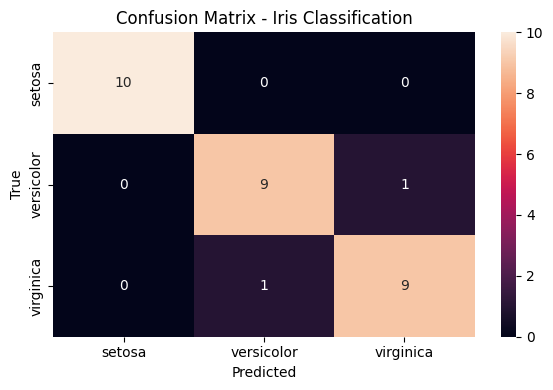


Trained model saved as 'iris_classification_model.pkl'


In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns  # optional, only for pretty plots

# 2. Load the Iris Dataset
iris = load_iris()
X = iris.data          # Features
y = iris.target        # Labels
feature_names = iris.feature_names
target_names = iris.target_names

print("Feature names:", feature_names)
print("Target classes:", target_names)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Convert to DataFrame (for better understanding & EDA)
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].apply(lambda i: target_names[i])

print("\nFirst 5 rows of the dataset:")
print(df.head())

# 3. Train-Test Split
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# 4. Build a Classification Pipeline
# StandardScaler + Logistic Regression
model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

# 5. Train the Model
model.fit(X_train, y_train)
print("\nModel training completed.")

# 6. Evaluate the Model
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("\n=== Evaluation Results ===")
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=target_names,
            yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Iris Classification")
plt.tight_layout()
plt.show()

# 8. Save the Trained Model (Optional but good for showing deployment readiness)
import joblib
joblib.dump(model, "iris_classification_model.pkl")
print("\nTrained model saved as 'iris_classification_model.pkl'")